# cAMP Excitation Waves in *Dictyostelium discoideum* — 2-Variable Model

## Biology in one paragraph
During starvation, *Dictyostelium* cells coordinate via extracellular cAMP. A pacemaker
cell releases a cAMP pulse, nearby cells detect it through the cAR1 surface receptor,
autocatalytically amplify and re-secrete cAMP, then enter a **refractory** (desensitised)
state before slowly recovering. The result: outward-propagating ring waves.

## Two-variable reduction
| variable | biological meaning |
|----------|--------------------|
| $c$ | extracellular cAMP (normalised) — **fast activator** |
| $r$ | fraction of cAR1 receptors in the **active** state — **slow inhibitor** |

$$\frac{dc}{dt} = \underbrace{k_s \, r \, \frac{c^2}{1+c^2}}_{\text{autocatalytic production}} \;-\; \underbrace{k_e \, c}_{\text{PDE degradation}}$$

$$\frac{dr}{dt} = \frac{r_\infty(c) - r}{\tau_r}, \qquad r_\infty(c) = \frac{1}{1+c^2}$$

**Key logic:**
- Production is zero at $c=0$ and saturates (Hill function with $n=2$) — true autocatalysis.
- High $c$ drives $r_\infty \to 0$: receptors desensitise → refractory period.
- After $c$ drops, $r$ slowly recovers → excitability restored.

Spatial coupling (Section 3): only **$c$ diffuses** extracellularly; $r$ is cell-intrinsic.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

## Section 1 — Parameters and model equations

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Parameters
# ══════════════════════════════════════════════════════════════════════════════
k_s   = 3.5    # max cAMP synthesis rate  (autocatalytic, gated by active receptors)
k_e   = 1.0    # cAMP degradation rate    (phosphodiesterase)
tau_r = 10.0   # receptor time constant   [slow → proper refractory period]

# Regime criterion
# The c-nullcline (dc/dt=0, c>0) and r-nullcline (dr/dt=0) have intersections
# for c>0  iff  k_s/k_e > 4  →  BISTABILITY.
# With k_s/k_e < 4 the nullclines do not cross for c>0 → single fixed point
# at (c=0, r=1) → EXCITABILITY.
print(f"k_s / k_e = {k_s/k_e:.2f}  (bistability threshold = 4.0)")
print(f"Regime    : {'EXCITABLE ✓' if k_s/k_e < 4 else 'BISTABLE — lower k_s or raise k_e'}")

# ── ODE right-hand sides (work element-wise on numpy arrays) ──────────────────
def f_c(c, r):
    """dc/dt — autocatalytic production minus degradation."""
    return k_s * r * c**2 / (1.0 + c**2) - k_e * c

def f_r(c, r):
    """dr/dt — relaxation of receptor activity toward steady state."""
    r_inf = 1.0 / (1.0 + c**2)
    return (r_inf - r) / tau_r

k_s / k_e = 3.50  (bistability threshold = 4.0)
Regime    : EXCITABLE ✓


## Phase portrait — nullclines and resting state

Excitation threshold (r=1, frozen):  c_th ≈ 0.314
  (cells below this decay back to rest; above this they fire)


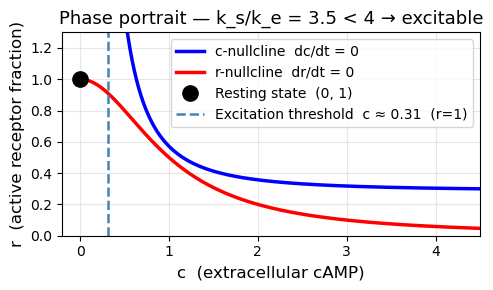

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Phase portrait
# ══════════════════════════════════════════════════════════════════════════════
c_grid = np.linspace(1e-3, 5.0, 600)
c_nc   = k_e * (1.0 + c_grid**2) / (k_s * c_grid**2)   # c-nullcline (dc/dt=0, c>0)
r_nc   = 1.0 / (1.0 + c_grid**2)                        # r-nullcline (dr/dt=0)

# Excitation threshold at r=1 (frozen inhibitor approximation):
# dc/dt = 0 at r=1  →  k_s c/(1+c²) = k_e  →  c² - (k_s/k_e)c + 1 = 0
disc   = (k_s/k_e)**2 - 4.0
c_th   = ((k_s/k_e) - np.sqrt(disc)) / 2.0
print(f"Excitation threshold (r=1, frozen):  c_th ≈ {c_th:.3f}")
print(f"  (cells below this decay back to rest; above this they fire)")

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(c_grid, np.clip(c_nc, 0, 1.4), 'b-', lw=2.5,
        label='c-nullcline  dc/dt = 0')
ax.plot(c_grid, r_nc,  'r-', lw=2.5,
        label='r-nullcline  dr/dt = 0')
ax.plot(0, 1, 'ko', ms=11, zorder=5,
        label='Resting state  (0, 1)')
ax.axvline(c_th, color='steelblue', ls='--', lw=1.8,
           label=f'Excitation threshold  c ≈ {c_th:.2f}  (r=1)')
ax.set_xlim(-0.2, 4.5); ax.set_ylim(0, 1.3)
ax.set_xlabel('c  (extracellular cAMP)', fontsize=12)
ax.set_ylabel('r  (active receptor fraction)', fontsize=12)
ax.set_title(f'Phase portrait — k_s/k_e = {k_s/k_e:.1f} < 4 → excitable', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 2 — Single-cell dynamics

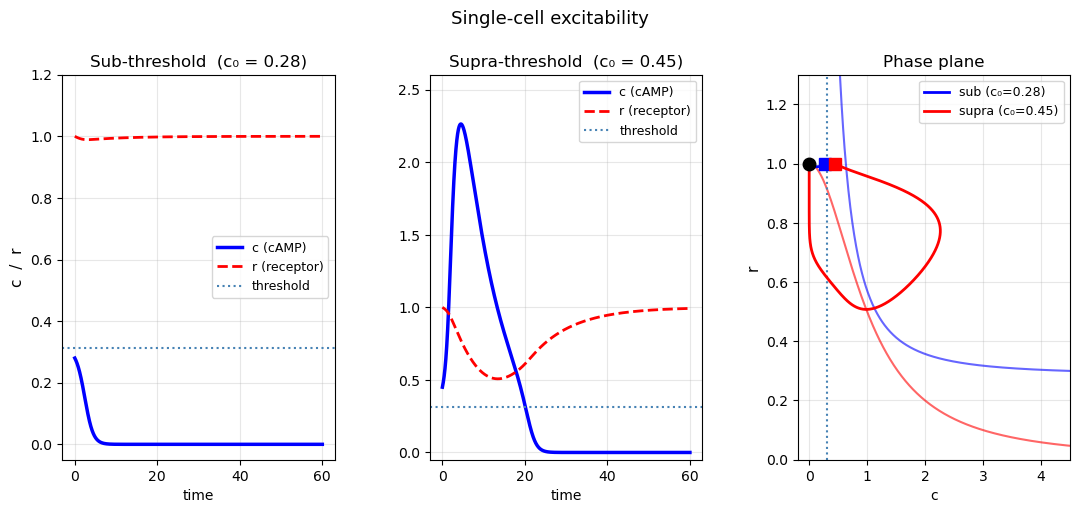

Peak cAMP (supra-threshold): 2.26  at t ≈ 4.5


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Section 2 — Single-cell dynamics
# ══════════════════════════════════════════════════════════════════════════════

def simulate_single(c0, r0=1.0, T=60.0, dt=0.01):
    """Forward-Euler integration of the single-cell ODE."""
    n = int(T / dt)
    c_h = np.empty(n + 1); r_h = np.empty(n + 1)
    c, r = float(c0), float(r0)
    c_h[0], r_h[0] = c, r
    for i in range(n):
        c = max(c + dt * f_c(c, r), 0.0)
        r = float(np.clip(r + dt * f_r(c, r), 0.0, 1.0))
        c_h[i+1], r_h[i+1] = c, r
    return np.linspace(0, T, n + 1), c_h, r_h

# Sub- and supra-threshold stimuli
t_sub, c_sub, r_sub = simulate_single(0.28)   # below c_th ≈ 0.314
t_sup, c_sup, r_sup = simulate_single(0.45)   # above c_th

fig = plt.figure(figsize=(13, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

c_pp  = np.linspace(1e-3, 5.0, 600)
c_nc2 = k_e * (1.0 + c_pp**2) / (k_s * c_pp**2)
r_nc2 = 1.0 / (1.0 + c_pp**2)

# Time trace — sub
ax0 = fig.add_subplot(gs[0])
ax0.plot(t_sub, c_sub, 'b-',  lw=2.5, label='c (cAMP)')
ax0.plot(t_sub, r_sub, 'r--', lw=2,   label='r (receptor)')
ax0.axhline(c_th, color='steelblue', ls=':', lw=1.5, label='threshold')
ax0.set_title('Sub-threshold  (c₀ = 0.28)', fontsize=12)
ax0.set_xlabel('time'); ax0.set_ylabel('c  /  r', fontsize=11)
ax0.legend(fontsize=9); ax0.grid(alpha=0.3); ax0.set_ylim(-0.05, 1.2)

# Time trace — supra
ax1 = fig.add_subplot(gs[1])
ax1.plot(t_sup, c_sup, 'b-',  lw=2.5, label='c (cAMP)')
ax1.plot(t_sup, r_sup, 'r--', lw=2,   label='r (receptor)')
ax1.axhline(c_th, color='steelblue', ls=':', lw=1.5, label='threshold')
ax1.set_title('Supra-threshold  (c₀ = 0.45)', fontsize=12)
ax1.set_xlabel('time'); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
ax1.set_ylim(-0.05, max(c_sup)*1.15)

# Phase plane
ax2 = fig.add_subplot(gs[2])
ax2.plot(c_pp, np.clip(c_nc2, 0, 1.4), 'b-', lw=1.5, alpha=0.6)
ax2.plot(c_pp, r_nc2, 'r-', lw=1.5, alpha=0.6)
ax2.axvline(c_th, color='steelblue', ls=':', lw=1.5)
ax2.plot(c_sub, r_sub, 'b-', lw=2,   label=f'sub (c₀=0.28)')
ax2.plot(c_sup, r_sup, 'r-', lw=2,   label=f'supra (c₀=0.45)')
ax2.plot(0, 1, 'ko', ms=9, zorder=5)
ax2.plot(c_sub[0], r_sub[0], 'bs', ms=8); ax2.plot(c_sup[0], r_sup[0], 'rs', ms=8)
ax2.set_xlim(-0.2, 4.5); ax2.set_ylim(0, 1.3)
ax2.set_xlabel('c'); ax2.set_ylabel('r', fontsize=11)
ax2.set_title('Phase plane', fontsize=12)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle('Single-cell excitability', fontsize=13, y=1.01)
plt.show()
print(f"Peak cAMP (supra-threshold): {c_sup.max():.2f}  at t ≈ {t_sup[c_sup.argmax()]:.1f}")

### Refractory period

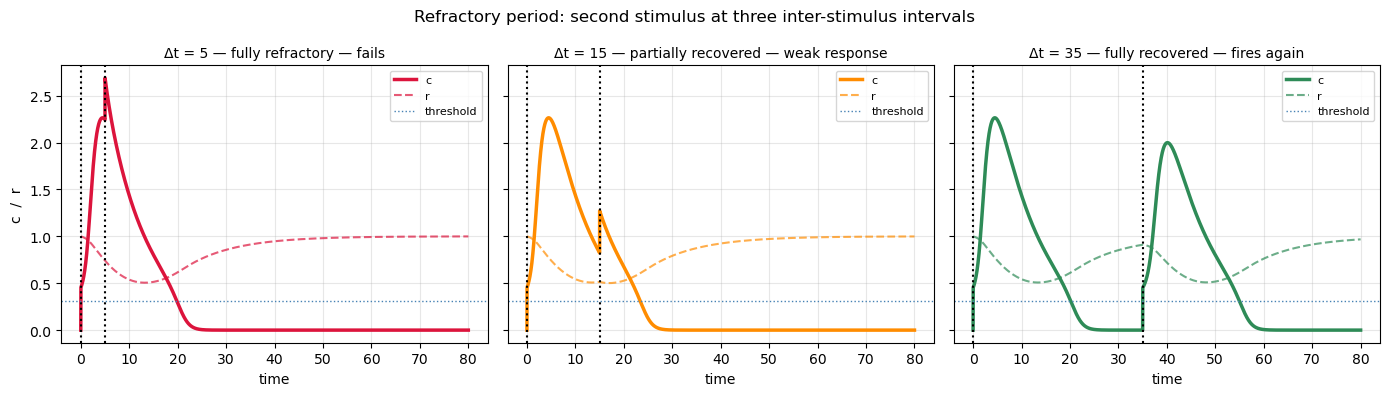

In [10]:
# ── Refractory period ──────────────────────────────────────────────────────────
# First stimulus at t=0; second at t=delay.
# Short delay → cell still refractory → second stimulus fails.

def simulate_two_pulses(delay, stim=0.45, T=80.0, dt=0.01):
    n = int(T / dt)
    d_step = int(delay / dt)
    c, r = 0.0, 1.0
    c_h = np.empty(n+1); r_h = np.empty(n+1)
    c_h[0], r_h[0] = c, r
    for i in range(n):
        if i == 0:       c += stim
        if i == d_step:  c += stim
        c = max(c + dt * f_c(c, r), 0.0)
        r = float(np.clip(r + dt * f_r(c, r), 0.0, 1.0))
        c_h[i+1], r_h[i+1] = c, r
    return np.linspace(0, T, n+1), c_h, r_h

delays = [5, 15, 35]
titles = [f'Δt = {d}' for d in delays]
descr  = ['fully refractory — fails',
          'partially recovered — weak response',
          'fully recovered — fires again']

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
cols = ['crimson', 'darkorange', 'seagreen']

for ax, d, ttl, dsc, col in zip(axes, delays, titles, descr, cols):
    t, ch, rh = simulate_two_pulses(d)
    ax.plot(t, ch, color=col, lw=2.5, label='c')
    ax.plot(t, rh, color=col, lw=1.5, ls='--', alpha=0.7, label='r')
    ax.axvline(0, color='k', ls=':', lw=1.5)
    ax.axvline(d, color='k', ls=':', lw=1.5)
    ax.axhline(c_th, color='steelblue', ls=':', lw=1, label='threshold')
    ax.set_title(f'{ttl} — {dsc}', fontsize=10)
    ax.set_xlabel('time'); ax.grid(alpha=0.3); ax.legend(fontsize=8)

axes[0].set_ylabel('c  /  r')
plt.suptitle('Refractory period: second stimulus at three inter-stimulus intervals',
             fontsize=12)
plt.tight_layout()
plt.show()

## Section 3 — 7-cell network: first wave spread

Before the 2-D PDE, we test wave spread on a minimal spatial scaffold:
**one centre cell** (cell 0) plus a **hexagonal ring** of 6 (cells 1–6):

```
   2 — 3
  /      \
 1   0    4
  \      /
   6 — 5
```
*(Edges also connect centre to all ring cells; shown simplified above.)*

**Coupling rule** — only extracellular $c$ diffuses; $r$ is cell-intrinsic:

$$\frac{dc_i}{dt} = f_c(c_i,r_i) \;+\; D \sum_j A_{ij} \frac{c_j - c_i}{\text{deg}_i}$$

Dividing by $\text{deg}_i$ normalises flux so the centre (deg = 6) and ring cells
(deg = 3) have the same effective diffusion rate.

**Note on the coupled threshold:** diffusive loss raises the effective firing
threshold for the centre from $c_{\rm th}^{\rm isolated}$ to a higher value.
This is why stimuli that fire an isolated cell may fail in the coupled network.

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Section 3 — 7-cell network
# ══════════════════════════════════════════════════════════════════════════════
D = 0.3   # diffusion (normalised by degree)

N = 7
A = np.zeros((N, N))
for i in range(1, 7):
    A[0, i] = A[i, 0] = 1.0          # centre ↔ each ring cell
    j = i % 6 + 1                     # next ring cell  (wrap 6 → 1)
    A[i, j] = A[j, i] = 1.0
deg = A.sum(axis=1)                   # [6, 3, 3, 3, 3, 3, 3]

# Cell positions (for network diagrams)
angles = np.linspace(0, 2*np.pi, 7)[:-1]
pos = np.zeros((N, 2))
pos[1:, 0] = np.cos(angles)
pos[1:, 1] = np.sin(angles)

# ── Coupled threshold (centre at rest, ring at c=0) ───────────────────────────
# dc_0/dt = f_c(c,1) - D*c = 0  →  k_s*c/(1+c²) = k_e + D
lhs = k_e + D
disc_c = (k_s/lhs)**2 - 4
c_th_coupled = ((k_s/lhs) - np.sqrt(disc_c)) / 2.0
print(f"Isolated threshold:  c_th_iso    ≈ {c_th:.3f}")
print(f"Coupled  threshold:  c_th_coupled ≈ {c_th_coupled:.3f}")
print(f"(A stimulus between these fires in isolation but NOT in the coupled network.)")

# ── Integrator ────────────────────────────────────────────────────────────────
def simulate_7cell(c_stim, T=100.0, dt=0.01, save_every=10):
    """Euler integration; only c diffuses."""
    n_steps = int(T / dt)
    c = np.zeros(N); r = np.ones(N)
    c[0] = c_stim
    t_h = [0.0]; c_h = [c.copy()]; r_h = [r.copy()]
    for step in range(n_steps):
        diffusion = D * (A @ c - deg * c) / deg
        c = np.maximum(c + dt * (f_c(c, r) + diffusion), 0.0)
        r = np.clip(   r + dt *  f_r(c, r),              0.0, 1.0)
        if (step + 1) % save_every == 0:
            t_h.append((step + 1) * dt)
            c_h.append(c.copy()); r_h.append(r.copy())
    return np.array(t_h), np.array(c_h), np.array(r_h)

# ── Sub-threshold in coupled network (c_stim = 0.40 < c_th_coupled) ──────────
print("\n--- Sub-threshold stimulus (c_stim = 0.40) ---")
t_s, C_s, R_s = simulate_7cell(c_stim=0.40)
print(f"Centre peak:  {C_s[:,0].max():.3f}   (decays to rest)")

# ── Supra-threshold: wave propagates ──────────────────────────────────────────
print("\n--- Supra-threshold stimulus (c_stim = 0.50) ---")
t, C, R = simulate_7cell(c_stim=0.50)
labels = ['Centre (0)'] + [f'Ring {i}' for i in range(1, 7)]
t_peak = np.array([t[C[:,i].argmax()] for i in range(N)])
c_peak = np.array([C[:,i].max()       for i in range(N)])
for i in range(N):
    print(f"  {labels[i]:12s}:  peak c = {c_peak[i]:.2f}  at t = {t_peak[i]:.1f}")

Isolated threshold:  c_th_iso    ≈ 0.314
Coupled  threshold:  c_th_coupled ≈ 0.445
(A stimulus between these fires in isolation but NOT in the coupled network.)

--- Sub-threshold stimulus (c_stim = 0.40) ---
Centre peak:  0.400   (decays to rest)

--- Supra-threshold stimulus (c_stim = 0.50) ---
  Centre (0)  :  peak c = 1.61  at t = 11.6
  Ring 1      :  peak c = 2.17  at t = 11.5
  Ring 2      :  peak c = 2.17  at t = 11.5
  Ring 3      :  peak c = 2.17  at t = 11.5
  Ring 4      :  peak c = 2.17  at t = 11.5
  Ring 5      :  peak c = 2.17  at t = 11.5
  Ring 6      :  peak c = 2.17  at t = 11.5


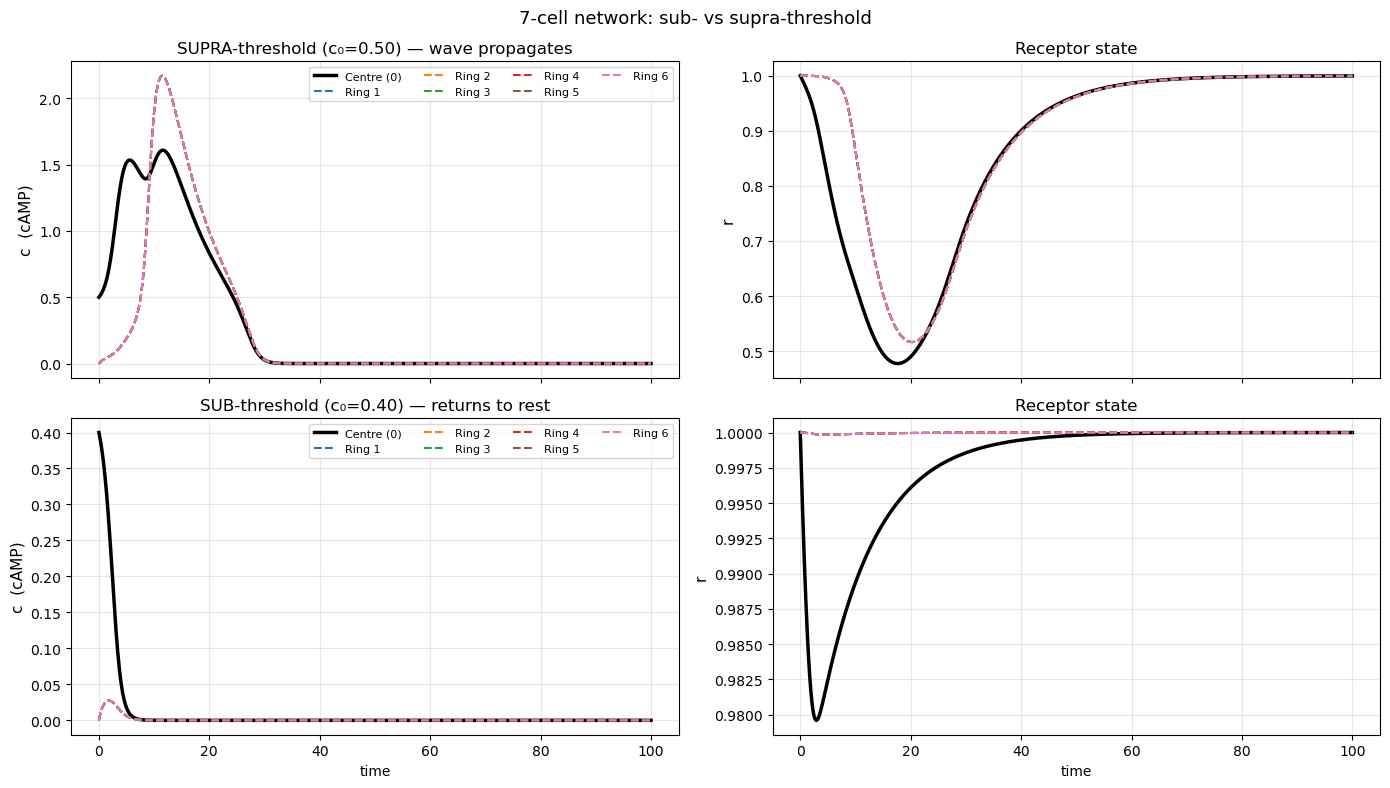

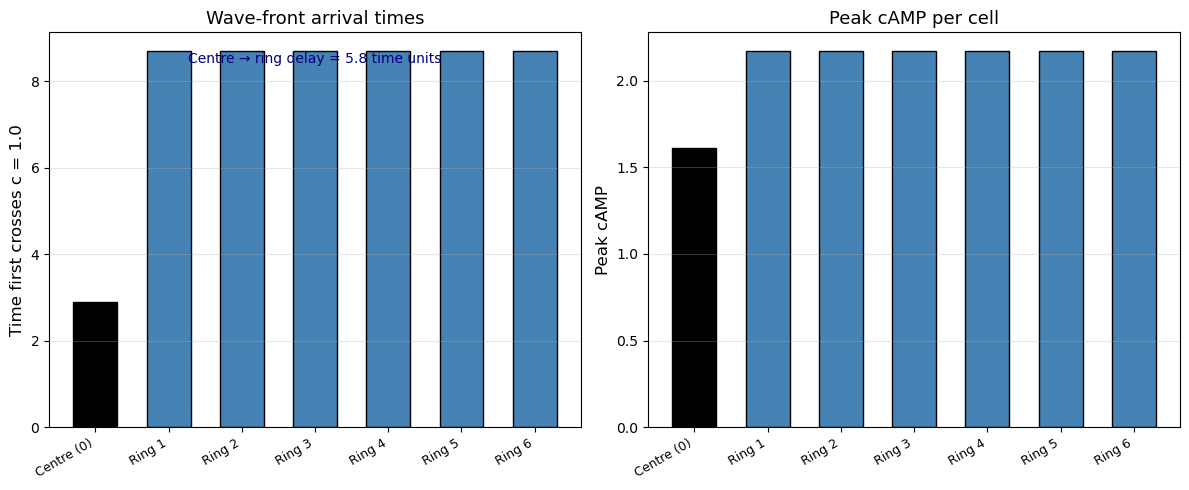

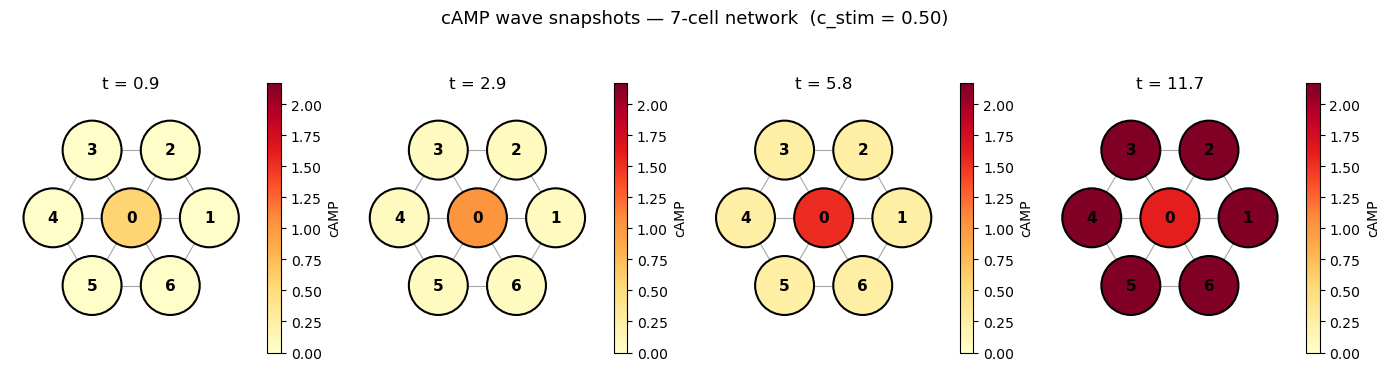

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Visualisation
# ══════════════════════════════════════════════════════════════════════════════
palette = ['black'] + list(plt.cm.tab10(np.linspace(0, 0.65, 6)))

# ── 1. Time traces: sub vs supra in the network ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

# Supra — cAMP
for i, (lbl, col) in enumerate(zip(labels, palette)):
    lw = 2.5 if i==0 else 1.5; ls = '-' if i==0 else '--'
    axes[0,0].plot(t,   C[:,i],   color=col, lw=lw, ls=ls, label=lbl)
    axes[0,1].plot(t,   R[:,i],   color=col, lw=lw, ls=ls, label=lbl)
    axes[1,0].plot(t_s, C_s[:,i], color=col, lw=lw, ls=ls, label=lbl)
    axes[1,1].plot(t_s, R_s[:,i], color=col, lw=lw, ls=ls, label=lbl)

axes[0,0].set_title('SUPRA-threshold (c₀=0.50) — wave propagates', fontsize=12)
axes[0,0].set_ylabel('c  (cAMP)', fontsize=11); axes[0,0].grid(alpha=0.3)
axes[0,0].legend(fontsize=8, ncol=4, loc='upper right')

axes[0,1].set_title('Receptor state', fontsize=12)
axes[0,1].set_ylabel('r', fontsize=11); axes[0,1].grid(alpha=0.3)

axes[1,0].set_title('SUB-threshold (c₀=0.40) — returns to rest', fontsize=12)
axes[1,0].set_ylabel('c  (cAMP)', fontsize=11); axes[1,0].set_xlabel('time')
axes[1,0].grid(alpha=0.3); axes[1,0].legend(fontsize=8, ncol=4, loc='upper right')

axes[1,1].set_title('Receptor state', fontsize=12)
axes[1,1].set_ylabel('r', fontsize=11); axes[1,1].set_xlabel('time')
axes[1,1].grid(alpha=0.3)

plt.suptitle('7-cell network: sub- vs supra-threshold', fontsize=13)
plt.tight_layout(); plt.show()

# ── 2. Activation sequence bar chart ─────────────────────────────────────────
# Use the time each cell first crosses c=1.0 (well into the excited state)
# to clearly show the propagation delay; peaks occur nearly simultaneously.
cross_lev = 1.0
t_cross = np.full(N, np.nan)
for i in range(N):
    idx_c = np.where(C[:, i] > cross_lev)[0]
    if len(idx_c): t_cross[i] = t[idx_c[0]]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bar_cols = ['black'] + ['steelblue']*6
axes[0].bar(range(N), np.nan_to_num(t_cross), color=bar_cols, edgecolor='k', width=0.6)
axes[0].set_xticks(range(N))
axes[0].set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel(f'Time first crosses c = {cross_lev}', fontsize=12)
axes[0].set_title('Wave-front arrival times', fontsize=13)
axes[0].grid(alpha=0.3, axis='y')
if not np.isnan(t_cross[0]) and not np.isnan(t_cross[1]):
    delay_cross = t_cross[1] - t_cross[0]
    axes[0].text(0.5, 0.95, f'Centre → ring delay = {delay_cross:.1f} time units',
                 ha='center', va='top', transform=axes[0].transAxes,
                 fontsize=10, color='navy')

# Peak cAMP per cell
axes[1].bar(range(N), c_peak, color=bar_cols, edgecolor='k', width=0.6)
axes[1].set_xticks(range(N)); axes[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Peak cAMP', fontsize=12)
axes[1].set_title('Peak cAMP per cell', fontsize=13)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

# ── 3. Network snapshots ──────────────────────────────────────────────────────
# Four snapshots spaced around the propagating wave front
t0 = t_cross[0] if not np.isnan(t_cross[0]) else t_peak[0]
t1 = t_cross[1] if not np.isnan(t_cross[1]) else t_peak[1]
snap_t = [t0 * 0.3, t0, (t0 + t1) / 2, t1 + 3]
snap_t = np.clip(snap_t, t[0], t[-1])

fig, snap_axes = plt.subplots(1, 4, figsize=(14, 4))
vmax = C.max()

for ax_s, ts in zip(snap_axes, snap_t):
    idx    = np.argmin(np.abs(t - ts))
    c_snap = C[idx]

    # Edges
    for i in range(N):
        for j in range(i+1, N):
            if A[i,j]:
                ax_s.plot([pos[i,0],pos[j,0]], [pos[i,1],pos[j,1]],
                          'k-', lw=0.8, alpha=0.35, zorder=1)
    # Nodes
    sc = ax_s.scatter(pos[:,0], pos[:,1], c=c_snap, cmap='YlOrRd',
                      s=1800, vmin=0, vmax=vmax, edgecolors='k', lw=1.5, zorder=2)
    for i in range(N):
        ax_s.text(pos[i,0], pos[i,1], str(i),
                  ha='center', va='center', fontsize=11, fontweight='bold', zorder=3)

    plt.colorbar(sc, ax=ax_s, shrink=0.8, label='cAMP')
    ax_s.set_title(f't = {t[idx]:.1f}', fontsize=12)
    ax_s.set_xlim(-1.55, 1.55); ax_s.set_ylim(-1.55, 1.55)
    ax_s.set_aspect('equal'); ax_s.axis('off')

fig.suptitle('cAMP wave snapshots — 7-cell network  (c_stim = 0.50)', fontsize=13)
plt.tight_layout(); plt.show()